# DeepSWE v1.1 empirical calibration

Calibration statistics for the case study (Table 3 and Figures 4 and 5 of the paper), computed
from the per-trial data that `prepare_data.py` writes to `data/`.
The default is **GPT-5.6 Sol** at **low, medium, high, xhigh, max** reasoning effort.
Set `MODEL` below to `gpt-5-6-luna` or `gpt-5-6-terra` to see the other two models; figures are saved only for Sol.

- Service value is the published binary `passed` outcome. **The four Sol trials that the publisher excluded because the verifier timed out count as failures (0)**, and their recorded costs and token usage are included.
- Costs are the **historical USD amounts recorded in the export**, not current-price estimates. Input, cached-input and output token counts remain in the data for anyone who wants to reprice.
- Each task is attempted four times at each effort. Distributions use individual trials; repetitions are not averaged or paired across efforts.
- The four excluded Sol trials are stored in a separate file with their original `included_in_score=false` and `score_value=null` fields. Counting them as failures is the paper's analysis convention, not a regrade by the publisher. The notebook merges both files.
- With these four trials, Sol has **452 trials (113 tasks times four repetitions) at every effort**. Luna and Terra use only their scored trials. Summaries weight trials equally; an equal-task-weighted rate is also reported. Costs do not include unrecorded retry overhead.

Sources: [trial export](https://deepswe.datacurve.ai/artifacts/v1.1/trials.json), [release notes](https://deepswe.datacurve.ai/blog/deepswe-v1-1), and [grading review](https://epoch.ai/benchmarks/deepswe/review).
The review identifies grading defects in v1.1. The published labels are used unchanged; apart from the timeout convention above, the analysis does not regrade any trial and does not establish the validity of the published grading.

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import hashlib
import html
import json

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, StrMethodFormatter
import numpy as np
from IPython.display import HTML, display

MODEL = "gpt-5-6-sol"  # Also: gpt-5-6-luna, gpt-5-6-terra
EFFORTS = ["low", "medium", "high", "xhigh", "max"]
TARGET_MEAN_SERVICE_TIME = 1.0

# Support launching from the notebook folder, Code/, or the repository root.
BASE = next((p for p in [Path.cwd(), Path.cwd()/"Case Study DeepSWE",
                        Path.cwd()/"Code"/"Case Study DeepSWE"]
             if (p/"data"/"manifest.json").is_file()), None)
if BASE is None:
    raise FileNotFoundError("Launch from this notebook's folder or the repository root.")
manifest = json.loads((BASE/"data"/"manifest.json").read_text(encoding="utf-8"))
data_path = BASE/"data"/manifest["file"]
content = data_path.read_bytes()
assert hashlib.sha256(content).hexdigest() == manifest["sha256"], "Snapshot checksum mismatch"
records = json.loads(content.decode("utf-8-sig"))
assert len(records) == manifest["record_count"]
assert all(r["source"] == "deep-swe" and r["included_in_score"] is True for r in records)
# Add the publisher-excluded Sol trials without rewriting their source labels.
supplemental = []
for entry in manifest["supplemental_files"]:
    raw = (BASE/"data"/entry["file"]).read_bytes()
    assert hashlib.sha256(raw).hexdigest() == entry["sha256"]
    extra = json.loads(raw.decode("utf-8-sig"))
    assert len(extra) == entry["record_count"]
    supplemental.extend(extra)
assert len(supplemental) == 4
assert all(r["model"] == "gpt-5-6-sol" and r["source"] == "deep-swe"
           and r["included_in_score"] is False and r["score_value"] is None
           and r["error_category"] == "verifier_timeout" for r in supplemental)
records = records + supplemental
assert len(records) == manifest["analysis_record_count"]

def analysis_success(record):
    # Publisher-excluded verifier timeouts count as incorrect (the paper's convention).
    return int(record["passed"]) if record["included_in_score"] else 0

selected = [r for r in records if r["model"] == MODEL]
if not selected:
    raise ValueError(f"No saved records for {MODEL}")
assert {r["reasoning_effort"] for r in selected} == set(EFFORTS)
assert len({r["trial_name"] for r in selected}) == len(selected), "Duplicate trial IDs"
assert all(type(r["passed"]) is bool for r in selected)
for r in selected:
    for field in ["cost_usd", "n_input_tokens", "n_cache_tokens", "n_output_tokens"]:
        assert isinstance(r[field], (int, float)) and np.isfinite(r[field]) and r[field] >= 0
    assert r["n_cache_tokens"] <= r["n_input_tokens"]
    if r["included_in_score"]:
        assert r["score_value"] == int(r["passed"])
    else:
        assert analysis_success(r) == 0 and r["error_category"] == "verifier_timeout"

by_effort = {e: [r for r in selected if r["reasoning_effort"] == e] for e in EFFORTS}
if MODEL == "gpt-5-6-sol":
    assert all(len(by_effort[e]) == 452 for e in EFFORTS)
    assert all(set(Counter(r["task_name"] for r in by_effort[e]).values()) == {4} for e in EFFORTS)
task_sets = [{r["task_name"] for r in by_effort[e]} for e in EFFORTS]
assert all(s == task_sets[0] for s in task_sets), "Efforts cover different tasks"
assert np.isfinite(TARGET_MEAN_SERVICE_TIME) and TARGET_MEAN_SERVICE_TIME > 0
costs = {e: np.array([r["cost_usd"] for r in by_effort[e]], dtype=float) for e in EFFORTS}
outcomes = {e: np.array([analysis_success(r) for r in by_effort[e]], dtype=float) for e in EFFORTS}
pooled_costs = np.concatenate([costs[e] for e in EFFORTS])
assert pooled_costs.mean() > 0
COST_TO_SERVICE_TIME = TARGET_MEAN_SERVICE_TIME / pooled_costs.mean()
service_times = {e: costs[e] * COST_TO_SERVICE_TIME for e in EFFORTS}
service_values = np.array([outcomes[e].mean() for e in EFFORTS])
mean_costs = np.array([costs[e].mean() for e in EFFORTS])
mean_service_times = mean_costs * COST_TO_SERVICE_TIME
assert np.isclose(np.concatenate(list(service_times.values())).mean(), TARGET_MEAN_SERVICE_TIME)

RESULTS = BASE/"results"  # Figures used in the paper.
COLORS = ["#4c78a8", "#59a14f", "#f28e2b", "#e15759", "#7a5195"]
plt.rcParams.update({"font.size": 11, "axes.titlesize": 13, "axes.labelsize": 12})

def finish(figure, paper_file=None):
    # Save only figures used in the paper, which reports GPT-5.6 Sol.
    if paper_file is not None and MODEL == "gpt-5-6-sol":
        RESULTS.mkdir(exist_ok=True)
        if paper_file.endswith(".pdf"):
            figure.savefig(RESULTS/paper_file, metadata={"CreationDate": None})
        else:
            figure.savefig(RESULTS/paper_file, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(figure)

def style(axis):
    axis.grid(alpha=0.2)
    axis.set_axisbelow(True)
    axis.spines[["top", "right"]].set_visible(False)

print(f"{MODEL}: {len(selected):,} analysis trials across {len(task_sets[0])} distinct tasks")
print("Trials per effort:", {e: len(by_effort[e]) for e in EFFORTS})
print(f"Cost-to-time coefficient: {COST_TO_SERVICE_TIME:.6f} normalized units/USD")
print("Cost basis: historical cost_usd; service time is a cost-based proxy, not seconds.")

print("Publisher-excluded trials counted as incorrect:", sum(not r["included_in_score"] for r in selected))


gpt-5-6-sol: 2,260 analysis trials across 113 distinct tasks
Trials per effort: {'low': 452, 'medium': 452, 'high': 452, 'xhigh': 452, 'max': 452}
Cost-to-time coefficient: 0.256657 normalized units/USD
Cost basis: historical cost_usd; service time is a cost-based proxy, not seconds.
Publisher-excluded trials counted as incorrect: 4


## Summary statistics

For effort $k$, with $n_k$ included analysis trials, $V(d_k)=n_k^{-1}\sum_i Y_{ik}$.
The table also reports cost quantiles and the second raw service-time moment
$E[S_k^2]$. The equal-task-weighted rate first averages each task's
observed repetitions, then averages across tasks. Repeated trials are not independent tasks.
No confidence intervals or statistical significance claims are made here.

For Sol, verifier timeouts contribute zero to success and their full recorded cost to expenditure. The table reports their count separately.


In [2]:
summary = []
for e in EFFORTS:
    trials = by_effort[e]
    task_outcomes = defaultdict(list)
    for r in trials:
        task_outcomes[r["task_name"]].append(analysis_success(r))
    repetitions = [len(v) for v in task_outcomes.values()]
    c, s = costs[e], service_times[e]
    summary.append({
        "effort": e, "n_tasks": len(task_outcomes), "n_trials": len(trials),
        "min_repeats_per_task": min(repetitions), "max_repeats_per_task": max(repetitions),
        "n_excluded_counted_incorrect": sum(not r["included_in_score"] for r in trials),
        "n_passed": int(outcomes[e].sum()), "accuracy": float(outcomes[e].mean()),
        "accuracy_equal_task_weight": float(np.mean([np.mean(v) for v in task_outcomes.values()])),
        "mean_cost_usd": float(c.mean()), "median_cost_usd": float(np.median(c)),
        "p95_cost_usd": float(np.quantile(c, .95)), "max_cost_usd": float(c.max()),
        "mean_input_tokens": float(np.mean([r["n_input_tokens"] for r in trials])),
        "mean_cached_input_tokens": float(np.mean([r["n_cache_tokens"] for r in trials])),
        "mean_output_tokens": float(np.mean([r["n_output_tokens"] for r in trials])),
        "mean_service_time": float(s.mean()), "second_raw_service_moment": float(np.mean(s*s)),
        "service_time_cv": float(s.std(ddof=0)/s.mean()),
    })
headers = ["Effort", "Tasks", "Trials", "Timeouts counted incorrect", "Success", "Task-weighted success",
           "Mean cost (USD)", "Median cost", "95th percentile cost", "Mean service time", "E[S^2]"]
body = []
for r in summary:
    values = [r["effort"], str(r["n_tasks"]), str(r["n_trials"]), str(r["n_excluded_counted_incorrect"]), f'{r["accuracy"]:.2%}',
              f'{r["accuracy_equal_task_weight"]:.2%}', f'${r["mean_cost_usd"]:.4f}',
              f'${r["median_cost_usd"]:.4f}', f'${r["p95_cost_usd"]:.4f}',
              f'{r["mean_service_time"]:.3f}', f'{r["second_raw_service_moment"]:.3f}']
    body.append("<tr>" + "".join(f"<td style='padding:6px;text-align:right'>{html.escape(v)}</td>" for v in values) + "</tr>")
display(HTML("<table><thead><tr>" + "".join(f"<th style='padding:6px'>{h}</th>" for h in headers)
             + "</tr></thead><tbody>" + "".join(body) + "</tbody></table>"))
print("Strictly increasing observed accuracy:", bool(np.all(np.diff(service_values) > 0)))
print("Strictly increasing observed mean cost:", bool(np.all(np.diff(mean_costs) > 0)))
print(f"Highest/lowest mean cost: {mean_costs[-1]/mean_costs[0]:.2f}x")
print("These are observed averages, not evidence of monotonicity for every task.")


Effort,Tasks,Trials,Timeouts counted incorrect,Success,Task-weighted success,Mean cost (USD),Median cost,95th percentile cost,Mean service time,E[S^2]
low,113,452,0,45.35%,45.35%,$1.0743,$0.9446,$2.0565,0.276,0.094
medium,113,452,0,61.06%,61.06%,$1.8620,$1.5454,$4.0676,0.478,0.297
high,113,452,1,69.25%,69.25%,$3.4673,$2.9791,$6.8664,0.890,1.009
xhigh,113,452,1,70.58%,70.58%,$4.7076,$4.1173,$9.3642,1.208,1.842
max,113,452,2,72.35%,72.35%,$8.3700,$6.8271,$17.5559,2.148,6.632


Strictly increasing observed accuracy: True
Strictly increasing observed mean cost: True
Highest/lowest mean cost: 7.79x
These are observed averages, not evidence of monotonicity for every task.


## 1. Service value and mean service time by reasoning depth

These are the two panels of the paper's calibration figure. Service value is the binary
success rate, including scored successes, scored failures, and Sol verifier timeouts
counted as incorrect. Mean service time uses the common cost-to-time factor defined in
Section 2. The connecting lines are visual guides between discrete effort settings.


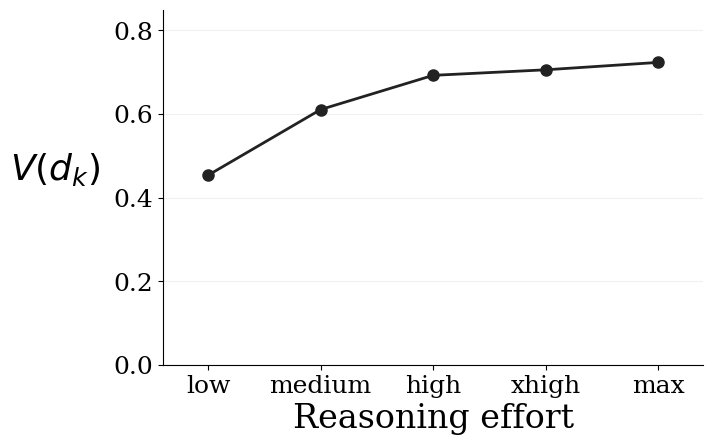

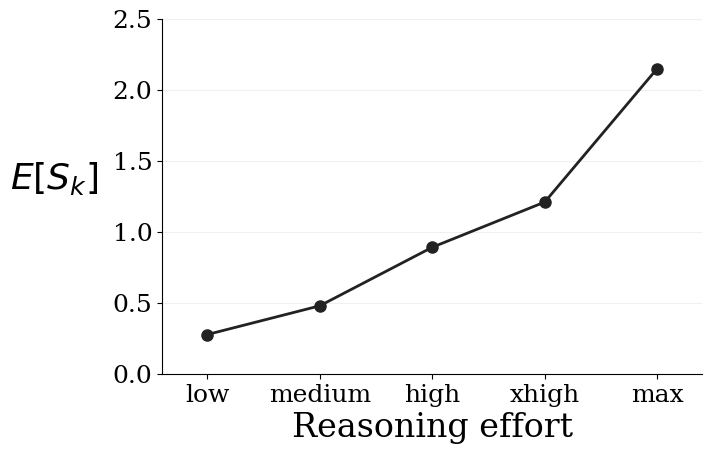

In [3]:
PAPER_STYLE = {"font.family": "serif"}

def effort_panel(values, ylabel, ymax, paper_file):
    """One panel of the paper's calibration figure: a statistic against reasoning effort."""
    with plt.rc_context(PAPER_STYLE):
        figure, axis = plt.subplots(figsize=(7.2, 4.8))
        positions = np.arange(len(EFFORTS))
        axis.plot(positions, values, color="#222222", linewidth=2, marker="o", markersize=8)
        axis.set_xticks(positions, EFFORTS)
        axis.set_xlim(-.4, len(EFFORTS) - .6)
        axis.set_ylim(0, ymax)
        axis.set_xlabel("Reasoning effort", fontsize=24)
        axis.set_ylabel(ylabel, fontsize=26, rotation=0, labelpad=18)
        axis.yaxis.set_label_coords(-.2, .5)
        axis.tick_params(labelsize=18)
        axis.grid(axis="y", alpha=.18)
        axis.spines[["top", "right"]].set_visible(False)
        figure.subplots_adjust(left=.21, right=.96, top=.95, bottom=.21)
        finish(figure, paper_file)

effort_panel(service_values, r"$V(d_k)$", .85, "service_value_by_effort.pdf")
effort_panel(mean_service_times, r"$E[S_k]$", 2.5, "service_time_by_effort.pdf")


## 2. Cost-based service-time distributions

Define $S_{ik}=\kappa C_{ik}$, where
$\kappa=1/\overline C$ for the default target mean of one. The pooled mean includes
all included analysis trials across all five efforts, with **one shared scaling factor**.
These are normalized cost-based service requirements, not measured processing seconds.
They do not establish that dollar expenditure is proportional to occupied server time.

The panels use identical bin edges and axes. No tails are trimmed. Bars show the number of trials in each bin (452 trials at every effort for Sol). The CDF below
provides a clearer view of the low-effort distributions compressed by the full common range.


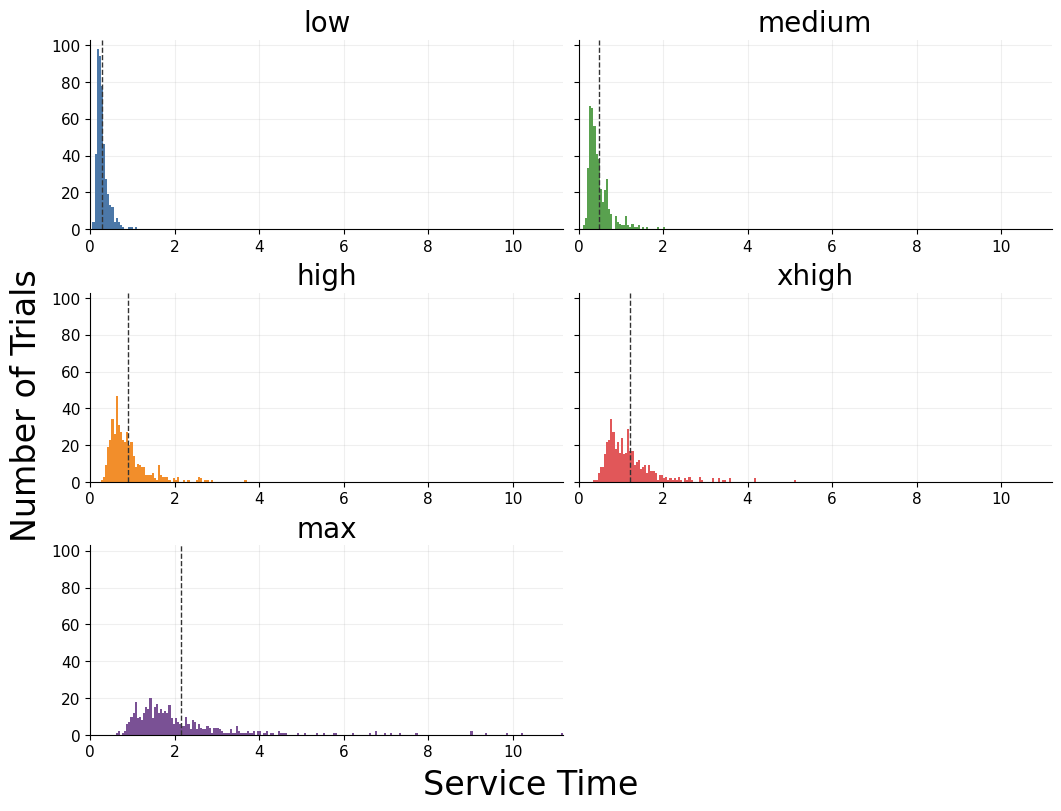

In [4]:
SERVICE_TIME_BIN_WIDTH = 0.05 * TARGET_MEAN_SERVICE_TIME
pooled_times = np.concatenate([service_times[e] for e in EFFORTS])
axis_max = np.ceil(pooled_times.max()/SERVICE_TIME_BIN_WIDTH)*SERVICE_TIME_BIN_WIDTH
bin_edges = np.linspace(0, axis_max, int(round(axis_max/SERVICE_TIME_BIN_WIDTH))+1)
figure, axes = plt.subplots(3, 2, figsize=(10.5, 8), sharex=True, sharey=True, layout="constrained")
for axis, effort, color in zip(axes.flat, EFFORTS, COLORS):
    s = service_times[effort]
    axis.hist(s, bins=bin_edges, color=color, linewidth=0)
    axis.axvline(s.mean(), color="#333333", linestyle="--", linewidth=1)
    axis.set_title(effort, fontsize=20)
    axis.set_xlim(0, axis_max)
    axis.tick_params(axis="x", labelbottom=True)
    style(axis)
axes.flat[-1].set_visible(False)
figure.supxlabel("Service Time", fontsize=24)
figure.supylabel("Number of Trials", fontsize=24)
finish(figure, "service_time_histograms.png")


## 3. Service value versus mean service time

The x-coordinate is the mean service time under the common cost-based normalization.
The **outside option** at $(0,0)$ is an assumed no-service policy, not a benchmark run.
It is excluded from every average and the normalization. Connecting segments are
visual guides, not an estimated continuous value function or a claim of concavity.


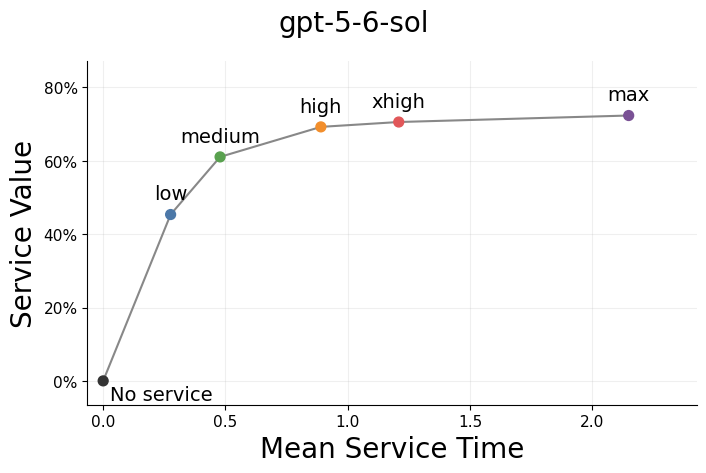

In [5]:
figure, axis = plt.subplots(figsize=(7.2, 4.8))
labels = ["No service", *EFFORTS]
values = np.r_[0., service_values]
plot_times = np.r_[0., mean_service_times]
axis.plot(plot_times, values, color="#888888", linewidth=1.5)
axis.scatter(plot_times, values, c=["#333333", *COLORS], s=50, zorder=3)
for label, mean_time, value in zip(labels, plot_times, values):
    offset = (5, -14) if label == "No service" else (0, 11)
    ha = "left" if label == "No service" else "center"
    axis.annotate(label, (mean_time, value), xytext=offset,
                  textcoords="offset points", ha=ha, fontsize=14)
axis.set(xlabel="Mean Service Time", ylabel="Service Value",
         xlim=(-.03*mean_service_times.max(), 1.13*mean_service_times.max()),
         ylim=(-.065, min(1.1, service_values.max()+.15)))
axis.yaxis.set_major_formatter(PercentFormatter(1))
axis.xaxis.label.set_size(20)
axis.yaxis.label.set_size(20)
style(axis)
figure.suptitle(MODEL, fontsize=20)
figure.tight_layout()
finish(figure)


## 4. Service-time distributions

The empirical CDF at time $t$ is the fraction of trials with service time at most $t$.
Each curve uses the normalized service times $S_{ik}=\kappa C_{ik}$ from the calibration,
with the same common conversion factor as the histograms and mean-service-time figure.
All included trials are retained, including the four Sol verifier timeouts.
The horizontal axis shows normalized service time on a linear scale, including the full upper tail;
these units are not dollars or measured seconds.
No-service is omitted because it is not an observed trial.


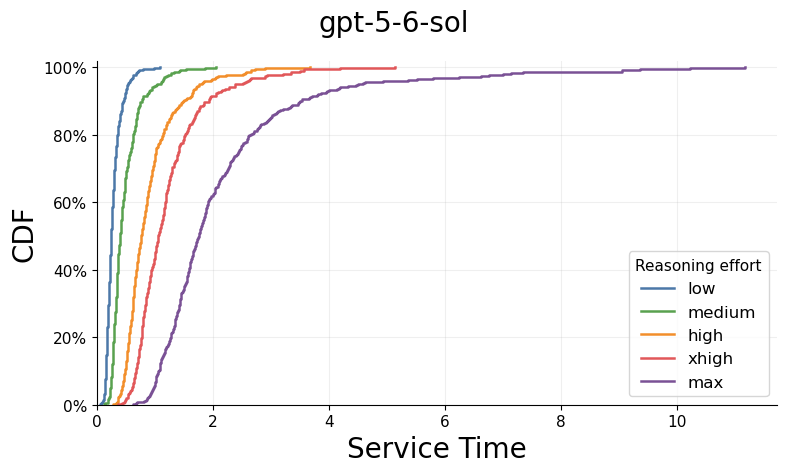

In [6]:
figure, axis = plt.subplots(figsize=(8, 4.8))
for effort, color in zip(EFFORTS, COLORS):
    times = np.sort(service_times[effort])
    axis.step(np.r_[times[0], times], np.r_[0., np.arange(1, len(times)+1)/len(times)],
              where="post", color=color, label=effort, linewidth=1.8)
axis.set_xlim(left=0)
axis.xaxis.set_major_formatter(StrMethodFormatter("{x:g}"))
axis.yaxis.set_major_formatter(PercentFormatter(1))
axis.set(xlabel="Service Time",
         ylabel="CDF", ylim=(0, 1.02))
axis.legend(title="Reasoning effort", fontsize=12)
axis.xaxis.label.set_size(20)
axis.yaxis.label.set_size(20)
style(axis)
figure.suptitle(MODEL, fontsize=20)
figure.tight_layout()
finish(figure)
